# Practical 5: Constrained Optimization: Equality and Inequality Constraints

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from QPGC import QPGenericConstraints

## Theoretical Background: Support Vector Machines and Constrained Optimization

For understand correctly the objectives of this practical delivery, we must take into account the following theorical approach for implement Support Vector Machines (SVMs) classifiers. So, SVMs are supervised learning methods designed to address binary classification problems by constructing a separating hyperplane with maximum margin. 

Given a training dataset $\{(x_i, y_i)\}_{i=1}^m$ with input vectors $x_i \in \mathbb{R}^n$ and labels $y_i \in \{-1, +1\}$, the objective is not only to correctly classify the samples but to do so in a way that maximizes robustness and generalization. This robustness is achieved by maximizing the margin, understood as the minimum distance between the separating hyperplane and the closest data points from each class.

In the linearly separable case, the classifier is defined by the affine function 

$$ f(x) = w^T x + b $$

where $w$ is the normal vector to the hyperplane and $b$ is a bias term. Correct classification with a margin constraint requires that all training samples satisfy 

$$y_i (w^T x_i + b) \geq 1$$

The margin corresponds to the distance between the two parallel hyperplanes $f(x) = 1$ and $f(x) = -1$, which can be shown to be equal to $2 / \|w\|$. Therefore, maximizing the margin is equivalent to minimizing the squared Euclidean norm of the weight vector.

This leads to the primal optimization problem:

$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{subject to} \quad y_i (w^T x_i + b) \geq 1$$

This is a convex optimization problem with linear inequality constraints. Instead of solving it directly, it is advantageous to derive its dual formulation using the method of Lagrange multipliers. Introducing multipliers $\alpha_i \geq 0$ associated with each constraint, the Lagrangian is defined as 

$$\mathcal{L}(w,b,\alpha) = \frac{1}{2}\|w\|^2 - \sum_{i=1}^m \alpha_i \left(y_i (w^T x_i + b) - 1\right)$$

The optimal solution corresponds to a saddle point of this Lagrangian. Enforcing stationarity with respect to $w$ and $b$ yields the conditions $$w = \sum_{i=1}^m \alpha_i y_i x_i$$ and $$\sum_{i=1}^m \alpha_i y_i = 0$$

These relations reveal a fundamental property of SVMs: the optimal separating hyperplane is entirely determined by a subset of the training samples, namely those with strictly positive multipliers. These samples are called support vectors and lie on or within the margin boundaries.

Substituting the stationarity conditions back into the Lagrangian leads to the dual optimization problem 

$$\max_{\alpha} \sum_{i=1}^m \alpha_i - \frac{1}{2} \sum_{i=1}^m \sum_{j=1}^m \alpha_i \alpha_j y_i y_j x_i^T x_j \quad \text{subject to} \quad \sum_{i=1}^m \alpha_i y_i = 0,\; \alpha_i \geq 0$$

This problem is a quadratic program with a linear equality constraint and non-negativity constraints. Since the objective function is concave, the solution is unique and corresponds to the global optimum. In practical scenarios, data are rarely perfectly separable. To account for this, slack variables $\xi_i \geq 0$ are introduced, allowing violations of the margin constraints. The primal problem becomes 

$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + K \sum_{i=1}^m \xi_i \quad \text{subject to} \quad y_i (w^T x_i + b) \geq 1 - \xi_i,\; \xi_i \geq 0$$

where the regularization parameter $K > 0$ controls the trade-off between maximizing the margin and penalizing classification errors.

The dual formulation in the non-separable case introduces upper bounds on the Lagrange multipliers, leading to $$\max_{\alpha} \sum_{i=1}^m \alpha_i - \frac{1}{2} \alpha^T (Y X^T X Y) \alpha \quad \text{subject to} \quad \sum_{i=1}^m \alpha_i y_i = 0,\; 0 \leq \alpha_i \leq K$$

This constrained quadratic optimization problem fits naturally within the framework of numerical linear algebra and can be solved efficiently using methods based on the Karush–Kuhn–Tucker conditions.

Once the optimal multipliers $\alpha^\star$ are obtained, the parameters of the classifier are reconstructed. The weight vector is computed as

$$w = \sum_{i=1}^m \alpha_i^\star y_i x_i $$

while the bias term can be estimated using any support vector satisfying $0 < \alpha_i < K$ through the relation $b = y_i - w^T x_i$. When several such support vectors exist, averaging the resulting values of $b$ improves numerical stability. Finally, the classifier is analyzed geometrically by visualizing the decision boundary $f(x) = 0$ together with the margin hyperplanes $f(x) = \pm 1$, which confirms that the support vectors lie exactly on the margin and illustrates the influence of the regularization parameter $K$ in both separable and non-separable cases.

**Explanationg of the  QPGC function:**

We want to solve the problem:

$$
\begin{aligned}
\max_{x} \quad
& \sum_{i=1}^m x_i
\;-\;
\frac{1}{2}x^T G x \\
\text{s.t.} \quad
& \sum_{i=1}^m y_i x_i = 0 \\
& 0 \le x_i \le K
\end{aligned}
$$

where $x \in \mathbb{R}^n$ is the lagrange multiplier for each point of the dataset and $ G = Y X^T X Y$.
 

This is equivalent to the problem

$$
\min_{x} - \sum_{i=1}^m x_i + \frac{1}{2}x^T G x  = g^T x + \frac{1}{2}x^T G x  
$$

where $g \in \mathbb{R}^m, g = (-1, \dots, -1)$

And we can turn the equality constraints into

$$
A^Tx = b,  
$$

Where $A = y$ and $b = 0$. We can turn the inequality constraints into

$$
x_i \ge 0, \qquad -x_i \ge -K.
$$

both inequallities can be expressed as

$$
\begin{bmatrix}
I \\
- I
\end{bmatrix} x
\ge
\begin{bmatrix}
0 \\
- K\mathbf{1}
\end{bmatrix}.
$$

Where $I$ is the identity matrix of range $n$. Thus, if we define

$$
C =
\begin{bmatrix}
I & -I
\end{bmatrix},
\qquad

\qquad
d =
\begin{bmatrix}
\underbrace{0, \; 0, \; \dots, \; 0}_{n \text{ times}},
\;
\underbrace{-K, \; -K, \; \dots, \; -K}_{n \text{ times}}
\end{bmatrix}^T


$$

The problem can be expressed appliying all changes as

$$
\begin{aligned}
\min_{x} \quad
& \frac{1}{2} x^T G x + g^T x \\
\text{s.t.} \quad
& A^T x = b, \\
& C^T x \ge d
\end{aligned}
$$



_The role of $K_

In the primal problem, the parameter $K$ controls the penalty on margin violations:

$$
\min \frac{1}{2}\|w\|^2 + K \sum_i \xi_i.
$$

- Large $K$: strong penalty for violations, smaller margin, risk of overfitting  
- Small $K$: weaker penalty, wider margin, more tolerance to misclassification  








---

## Proposed experiments

_In order to do this exercise you may use your own code associated to minimize (9). We also provide you with our own (compiled) implementation of the minimization of (9). The module is called `QPGC` and the function is `QPGenericConstraints`. Use the `help` function to know the parameters you have to pass to it._

_Implement the previous proposed algorithm and use the dataset with the following mean and covariance:_

```python
m1 = [0.,0.]
s1 = [[1,-0.9],[-0.9,1]]
m2 = [3.,6.]   s2 = [[1,0],[0,1]] # Separable dataset
#m2 = [1.,2.]  s2 = [[1,0],[0,1]] # Non-separable dataset
```

Fisrt, insteed of start doing the proposed experiments, we define de following functions which would help us to generate datasets (**create_dataset**), train an SVM using QPGenericConstraints with regularization parameter K (**SVM_hyperplane**), plot the dataset of each class (**plot_dataset**) and the plotting function for represent the dataset together with the SVM decision boundary and margin lines (**plot_svm_with_margin**). 

In [30]:
help(QPGenericConstraints)

Help on function QPGenericConstraints in module QPGC:

QPGenericConstraints(G, g, A, C, b, d)
    Convex optimization problem with equality and inequality constraints:
     
               min f(x)=1/2 x^T G X + g^T x     s.t.   A^T x = b i C^T x >= d
    
    Call it with:
    
    x = QPGenericConstrains(G, g, A, C, b, d)
    
    Notation:
    
    n = number of variables
    p = number of equality constants
    m = number of inequality constants
     
    Dimensions:   G -> n x n
                  g -> n x 1
                  A -> n x p
                  C -> n x m
                  b -> p x 1  
                  d -> m x 1



In [7]:
### Main functions ###

def create_dataset(m1, s1, m2, s2, n_samples=100, seed=None):
    """
    Create a binary classification dataset with two classes sampled from 
    multivariate normal distributions.
    
    Parameters
    ----------
    m1 : array-like
        Mean vector for class 1
    s1 : array-like
        Covariance matrix for class 1
    m2 : array-like
        Mean vector for class 2
    s2 : array-like
        Covariance matrix for class 2
    n_samples : int, optional
        Number of samples per class (default: 100)
    seed : int, optional
        Random seed for reproducibility (default: None)
    
    Returns
    -------
    X : ndarray of shape (2*n_samples, 2)
        Feature matrix with all data points
    y : ndarray of shape (2*n_samples,)
        Labels: +1 for class 1, -1 for class 2
    """
    if seed is not None:
        np.random.seed(seed)
    X1 = np.random.multivariate_normal(m1, s1, n_samples)
    y1 = np.ones(n_samples)
    X2 = np.random.multivariate_normal(m2, s2, n_samples)
    y2 = -np.ones(n_samples)
    X = np.vstack([X1, X2])
    y = np.concatenate([y1, y2])
    return X, y

def SVM_hyperplane(X, y, K=1.0):
    """
    Train an SVM using QPGenericConstraints with regularization parameter K.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    K : float
        Regularization parameter (C in soft-margin SVM).
    
    Returns
    -------
    w : ndarray
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    alphas : ndarray
        Lagrange multipliers.
    """
    n = X.shape[0]
    p = 1
    m = 2 * n
    # Matrices for QP
    A = y.reshape(n, p)
    b_vec = np.zeros(p)
    C = np.concatenate((np.eye(n), -np.eye(n)), axis=1)
    d = np.concatenate((np.zeros(n), -K * np.ones(n)))
    Y = np.diag(y)
    G = Y @ X @ X.T @ Y
    g = -np.ones(n)
    # Solve QP
    alphas = QPGenericConstraints(G, g, A, C, b_vec, d)
    # Compute w and b
    w = (alphas * y) @ X
    sv = (alphas > 1e-5)
    b = np.mean(y[sv] - X[sv] @ w)
    return w, b, alphas


In [8]:
### Plotting functions ###

def plot_dataset(X, y, ax=None, title="Classification Dataset"):
    """
    Plot the dataset with different colors and shapes for each class.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Feature matrix
    y : ndarray of shape (n_samples,)
        Labels: +1 for class 1, -1 for class 2
    ax : matplotlib.axes.Axes, optional
        Axes to plot on (default: creates new figure)
    title : str, optional
        Title for the plot (default: "Classification Dataset")
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the plot
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    mask1 = y == 1
    ax.scatter(X[mask1, 0], X[mask1, 1], c='blue', marker='o', s=50, alpha=0.7, label='Class +1', edgecolors='darkblue')
    mask2 = y == -1
    ax.scatter(X[mask2, 0], X[mask2, 1], c='red', marker='s', s=50, alpha=0.7, label='Class -1', edgecolors='darkred')
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    return ax

def plot_svm_with_margin(X, y, w, b, ax=None, title="SVM with Margin"):
    """
    Plot a 2D dataset together with the SVM decision boundary and margin lines.

    The plot is automatically centered on the data points, and the decision
    boundary along with its margins is drawn to span the full visible plot
    area for consistent scaling.

    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Input feature matrix containing 2D points.
    y : ndarray of shape (n_samples,)
        Class labels for each sample, expected to be +1 or -1.
    w : ndarray of shape (2,)
        Weight vector defining the SVM separating hyperplane.
    b : float
        Bias (intercept) term of the separating hyperplane.
    ax : matplotlib.axes.Axes, optional
        Existing matplotlib axes to plot on. If None, a new figure and axes
        are created.
    title : str, optional
        Title displayed at the top of the plot.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The matplotlib axes object containing the plot.
    """
     
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    plot_dataset(X, y, ax=ax)

    # ---- Compute data-based limits with padding ----
    pad = 0.15
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    x_range = x_max - x_min
    y_range = y_max - y_min

    x_min -= pad * x_range
    x_max += pad * x_range
    y_min -= pad * y_range
    y_max += pad * y_range

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # ---- Plot hyperplane and margins across full axes ----
    if abs(w[1]) > 1e-8:
        xx = np.array([x_min, x_max])

        # Decision boundary
        yy = (-w[0] * xx - b) / w[1]
        ax.plot(xx, yy, 'k-', linewidth=2, label='SVM hyperplane')

        # Margins
        yy_p = (-w[0] * xx - b + 1) / w[1]
        yy_m = (-w[0] * xx - b - 1) / w[1]

        ax.plot(xx, yy_p, 'b--', linewidth=2, label='Margin +1')
        ax.plot(xx, yy_m, 'r-.', linewidth=2, label='Margin -1')

    # ---- Improve visual scaling ----
    ax.set_aspect('equal', adjustable='box')  # prevents distortion
    ax.margins(0.05)                          # small internal padding
    ax.legend()
    ax.set_title(title)

    return ax





### Data generation

In this step, the datasets are generated using multivariate normal distributions in order to control both the spatial location and the dispersion of each class. Each class is modeled as a Gaussian random vector of the form $x \sim \mathcal{N}(\mu_k, \Sigma_k)$, where the mean vector $\mu_k$ determines the center of the class and the covariance matrix $\Sigma_k$ controls its shape and orientation. By modifying the relative positions of the class means and their covariance structures, it is possible to generate either linearly separable or non-separable datasets, which allows the analysis of the SVM behavior under different geometric conditions.

Here, we define the mean and covariance matrices for both classes.

In [9]:
# Class 1 parameters
m1 = [0., 0.]
s1 = [[1, -0.9], [-0.9, 1]]

# Class 2 parameters - Separable dataset
m2_separable = [3., 6.]
s2_separable = [[1, 0], [0, 1]]

# Class 2 parameters - Non-separable dataset 
m2_non_separable = [1., 2.]
s2_non_separable = [[1, 0], [0, 1]]

### Create and Visualize the Dataset

In order to plot both datasets, we use the function defined in the previos sections and we obtain the representation of both classes,

Separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


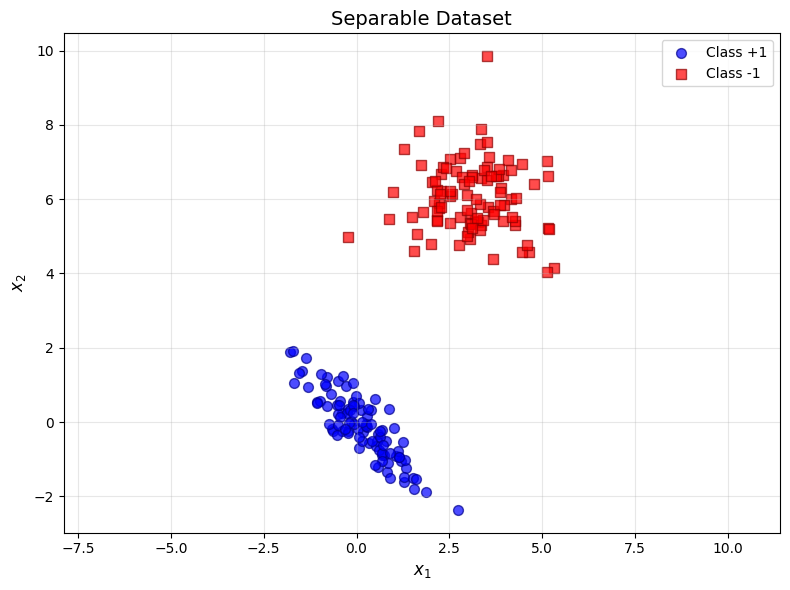

Non separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


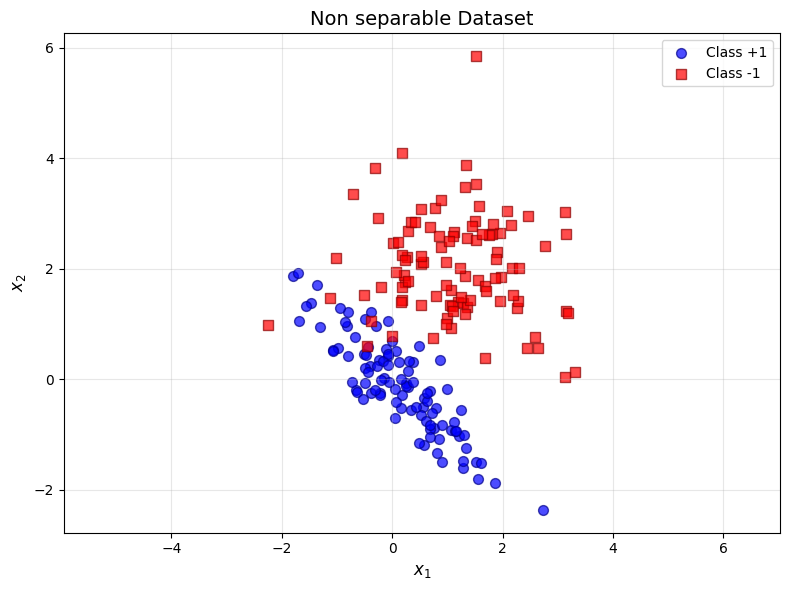

In [10]:
# Create the separable dataset
X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
print(f"Separable dataset created with {len(y_sep)} samples")
print(f"Class +1: {np.sum(y_sep == 1)} samples")
print(f"Class -1: {np.sum(y_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_sep, y_sep, title="Separable Dataset")
plt.tight_layout()
plt.show()

# Create the non-separable dataset
X_non_sep, y_non_sep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)
print(f"Non separable dataset created with {len(y_non_sep)} samples")
print(f"Class +1: {np.sum(y_non_sep == 1)} samples")
print(f"Class -1: {np.sum(y_non_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_non_sep, y_non_sep, title="Non separable Dataset")
plt.tight_layout()
plt.show()

### **Experiments**

_For the following experiments, it is interesting to plot the classification line at level lines $0$, $+1$ and $-1$._

#### Experiment 1

  * _You are recommended to begin with the simplest case, i.e. the case in which data is separable, and with a small dataset (2 points for each class, for instance). You are recommended to start with a relatively small value of $K$, e.g. $K = 1$. Plot the hyperplane $f(\mathbf{x}) = \mathbf{w}^T\mathbf{x} + b = 0$, as well as the hyperplane at distance $-1$ and $1$ respectively. Check if the hyperplane separates correctly the set of points and check that the hyperplanes at distance $-1$ and $1$ "touch" the support vectors._

---

w: [-0.18911393 -0.29661133]
b: 1.233280404617954


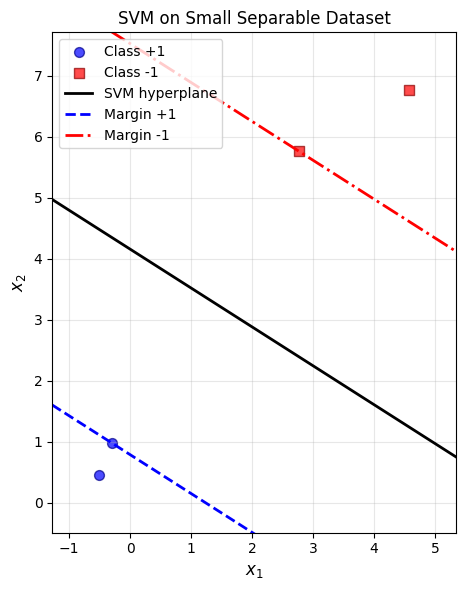

In [12]:
# Experiment 1. Separable dataset with 2 samples per class
X_small, y_small = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=2, seed=42)
w, b, _ = SVM_hyperplane(X_small, y_small, K=1.0)
print("w:", w)
print("b:", b)
plot_svm_with_margin(X_small, y_small, w, b, title="SVM on Small Separable Dataset")
plt.tight_layout()
plt.show()


In this first experiment, a simple linearly separable dataset with two samples per class is considered in order to validate the basic behavior of the Support Vector Machine in an ideal setting. A relatively small value of the regularization parameter $K = 1$ is used, which is sufficient in the separable case. The resulting classifier is defined by the decision function $f(x) = w^T x + b$, whose zero level set $f(x) = 0$ corresponds to the separating hyperplane shown in the figure. In addition, the margin hyperplanes $f(x) = +1$ and $f(x) = -1$ are plotted to visualize the maximum-margin structure. As expected from SVM theory, the closest points to the separating hyperplane lie exactly on these margin boundaries. In particular, one sample from the positive class satisfies $f(x_i) = +1$ and one sample from the negative class satisfies $f(x_j) = -1$, confirming that these points are support vectors and that the margin constraints are active. This geometric configuration verifies that the hyperplane correctly separates the dataset and that the margin is maximized, as the distance between the two margin hyperplanes is determined by the support vectors.


In [26]:
# Check MARGIN +1

print("Check point x1=" , X_small[1,:], "belong to hyperplane f(x1)=1?",1==round(w.T @ X_small[1,:] +b))
print("Check point x1=" , X_small[2,:], "belong to hyperplane f(x1)=-1?",-1==round(w.T @ X_small[2,:] +b))

Check point x1= [-0.29072887  0.97184853] belong to hyperplane f(x1)=1? True
Check point x1= [2.76584663 5.76586304] belong to hyperplane f(x1)=-1? True


#### Experiment 2

  * _Once it works, you may use a separable data set in which each class has 100 samples, for instance. Plot the obtained result and see if the hyperplane separates correctly the set of points._

---

w: [-0.25645704 -0.53182677]
b: 1.584289132127482


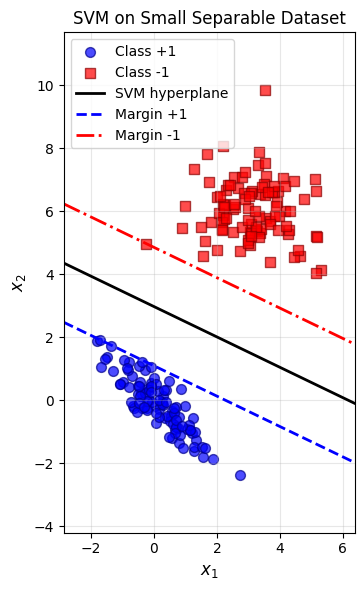

In [28]:
# Experiment 2. Separable dataset with 100 samples per class
X_small, y_small = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
w, b, _ = SVM_hyperplane(X_small, y_small, K=1.0)
print("w:", w)
print("b:", b)
plot_svm_with_margin(X_small, y_small, w, b, title="SVM on Small Separable Dataset")
plt.tight_layout()
plt.show()

In this second experiment, the size of the dataset is increased to 100 samples per class while maintaining linear separability. This larger sample size provides a more representative approximation of the underlying class distributions and allows us to assess the stability of the SVM solution. The resulting decision function $f(x) = w^T x + b$ still defines a separating hyperplane that correctly discriminates between the two classes. As shown in the figure, all samples from the positive and negative classes lie on opposite sides of the separating hyperplane, confirming correct classification of the separable dataset. Moreover, the margin hyperplanes $f(x) = +1$ and $f(x) = -1$ clearly bound the two classes, with only a small subset of points lying close to these margins and acting as support vectors. This demonstrates that, even with a significantly larger number of samples, the SVM maintains a stable maximum-margin solution, and the classification is governed by the geometry of the closest points rather than by the total number of observations.


#### Experiment 3

* Perform several experiments with different values of $K$ and test the stability of the solution you obtain. You may use small values of $K$, e.g. $K = 1$, as well as large values of $K$, e.g. $K = 10^6$ or higher such as $K = 10^{12}$. Repeat the experiment several times. Does the value of $K$ influence the solution you obtain? That is, does the hyperplane separate correctly the set of points you have? Can you explain the results? Recall that you are in the separable case, i.e. Eq (6) has no upper threshold for $\alpha$.

---

K=0.1
w: [-0.23536804 -0.45913213]
b: 1.4139718625003863


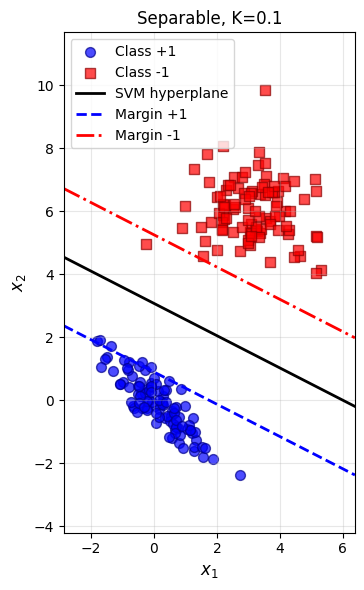

K=1
w: [-0.25645704 -0.53182677]
b: 1.584289132127482


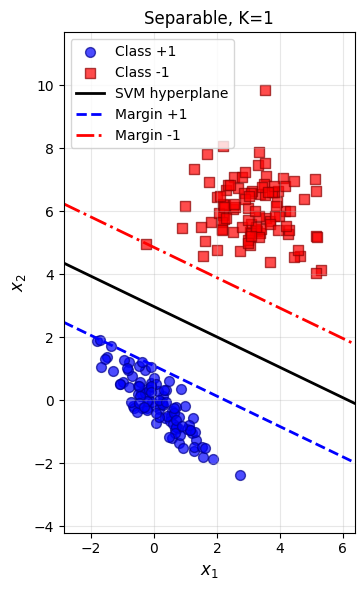

K=10
w: [-0.25601681 -0.53205559]
b: 1.5614494631661386


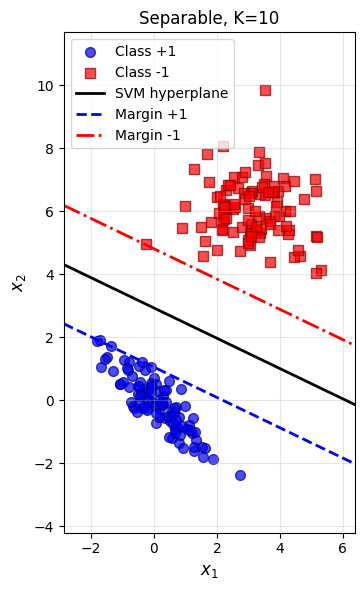

K=100
w: [-0.3395158  -0.79070328]
b: 2.899236384083972


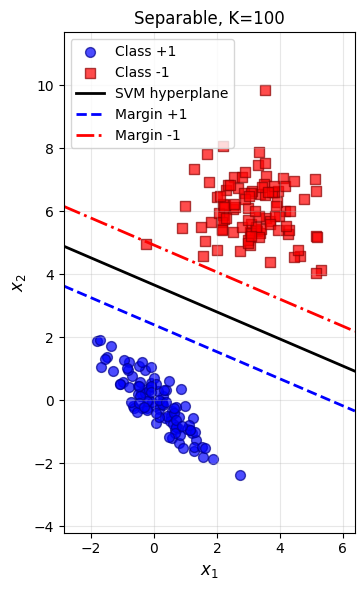

K=1000000.0
w: [nan nan]
b: nan


/Users/josecalatayud/anaconda3/envs/entorn_39/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/josecalatayud/anaconda3/envs/entorn_39/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


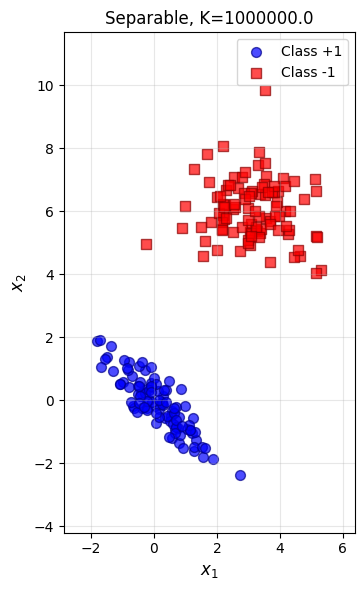

K=1000000000000.0
w: [nan nan]
b: nan


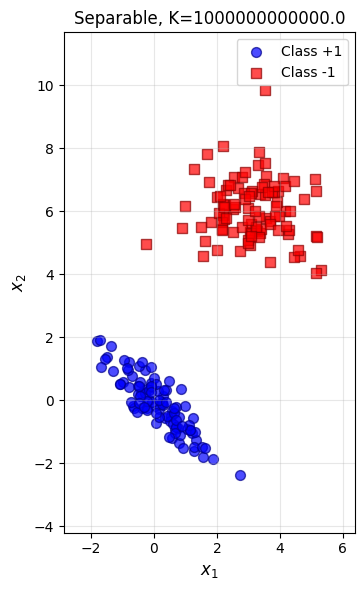

In [ ]:
# Experiment 3. Separable dataset, 100 samples per class, multiple K values
K_values = [0.1, 1, 10, 100, 1e6, 1e12]
for K in K_values:
    X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
    w_sep, b_sep, _ = SVM_hyperplane(X_sep, y_sep, K=K)
    print(f"K={K}")
    print("w:", w_sep)
    print("b:", b_sep)
    plot_svm_with_margin(X_sep, y_sep, w_sep, b_sep, title=f"Separable, K={K}")
    plt.tight_layout()
    plt.show()


In this third experiment, the behavior of the Support Vector Machine is analyzed on a linearly separable dataset with 100 samples per class while varying the regularization parameter $K$ over several orders of magnitude. For moderate values of $K$, such as $K = 0.1, 1, 10,$ and $100$, the resulting separating hyperplane $f(x) = w^T x + b$ remains essentially unchanged, and the classification of the dataset is identical in all cases. Perhaps, if you observe the representation for $K=0.1$, you can observe that the support-margins dont't classify separate each dataset, and we can ask ourselves a question: why is this happening if we're in the separate dataset (head-margin SVM)?. We will answer this question in the following parragraph. The margin hyperplanes $f(x) = \pm 1$ consistently bound the two classes, and the same subset of points acts as support vectors, confirming that in the separable case the solution corresponds to the hard-margin SVM and is largely independent of $K$. This behavior is expected, since no slack variables are required and the upper bound $K$ on the Lagrange multipliers is not active for the support vectors. However, when $K$ is increased to extremely large values, numerical instabilities appear in the optimization procedure, leading to undefined values of the parameters $w$ and $b$. This issue is not related to the theoretical formulation of the SVM, but rather to limitations in numerical precision when solving the quadratic programming problem with very large constraint bounds. Overall, this experiment confirms that for linearly separable data, the SVM solution is stable with respect to $K$, and only extreme values may cause numerical problems without altering the underlying geometric interpretation.

In these experiments, the optimization method used corresponds to the soft-margin SVM formulation, implemented as a quadratic programming problem with Karush–Kuhn–Tucker (KKT) conditions and box constraints on the Lagrange multipliers. This formulation is mathematically appropriate for non-separable datasets, where slack variables are required to allow margin violations and the objective function explicitly depends on the regularization parameter $K$, which controls the trade-off between margin maximization and misclassification penalty. However, in the experiments considered here, the dataset is linearly separable, and the correct theoretical model should therefore be the hard-margin SVM, whose objective function does not depend on any regularization constant.

By applying a soft-margin optimization scheme to a separable dataset, additional degrees of freedom are unintentionally introduced into the problem. In particular, the presence of slack variables and the box constraints $0 \le \alpha_i \le K$ allow the optimizer to treat the margin as “soft”, even though no violations are theoretically required. As a consequence, for small or moderate values of $K$, the solver may still recover a solution close to the hard-margin optimum (but not always), since the slack variables remain inactive and the margin constraints are approximately satisfied. However, the problem being solved is no longer the pure hard-margin SVM, but a relaxed version in which margin violations are permitted at a finite cost.

This explains why, in some of the plots, the classification is not perfectly correct despite the dataset being separable. The optimization algorithm is allowed to trade margin width against classification accuracy, even when such a trade-off is unnecessary from a theoretical point of view. As a result, some points may fall inside the margin or even be misclassified, not because separation is impossible, but because the soft-margin formulation does not enforce strict separation when $K$ is finite.

As the value of $K$ is increased, the penalty associated with slack variables becomes progressively larger. In the limit of very large $K$, the soft-margin objective increasingly resembles the hard-margin problem, since margin violations become extremely costly. However, from a numerical perspective, this limit is problematic. Large values of $K$ lead to poorly scaled quadratic programming problems, where the box constraints on the Lagrange multipliers span several orders of magnitude. This deteriorates the conditioning of the KKT system and amplifies floating-point errors, which can result in unstable solutions, excessively large values of the parameters $w$ and $b$, or even undefined numerical values.

Therefore, the observed behavior is the combined effect of a modeling mismatch and numerical limitations. Conceptually, a soft-margin SVM is being used to solve a problem that is intrinsically hard-margin, introducing unnecessary flexibility into the optimization. Numerically, increasing $K$ in an attempt to recover the hard-margin solution pushes the solver into an ill-conditioned regime, where stability is lost. In theory, the correct hard-margin solution should be independent of $K$; in practice, when using a soft-margin implementation, $K$ indirectly influences the solution and may cause both suboptimal classification and numerical instability when taken to extreme values.


#### Experiment 4 

* Test your algorithm with the non-separable case using different values of $K$. Repeat the experiment several times. Again, does the value of $K$ influence the solution you obtain? Can you explain the results?

---

K=0.001
w: [-0.10080029 -0.21485179]
b: 0.27116480406098253


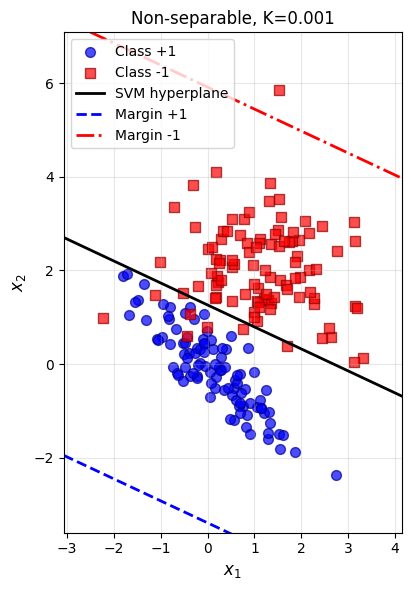

K=0.1
w: [-0.85217644 -1.1593091 ]
b: 1.1913063079291104


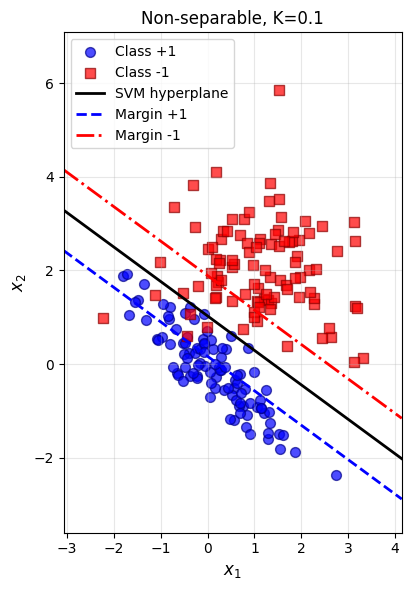

K=1
w: [-1.28731185 -1.76551683]
b: 1.609773599842561


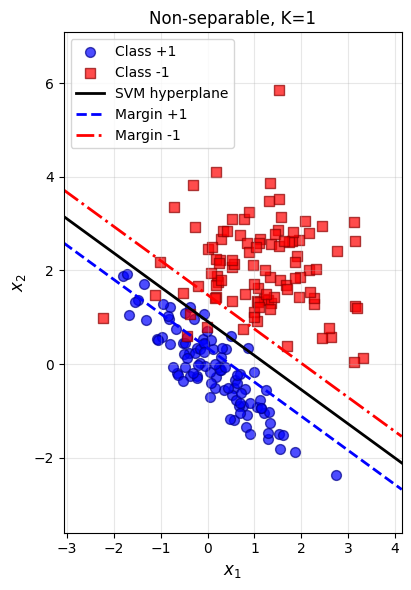

K=10
w: [-1.61387899 -2.43036997]
b: 2.114512370363465


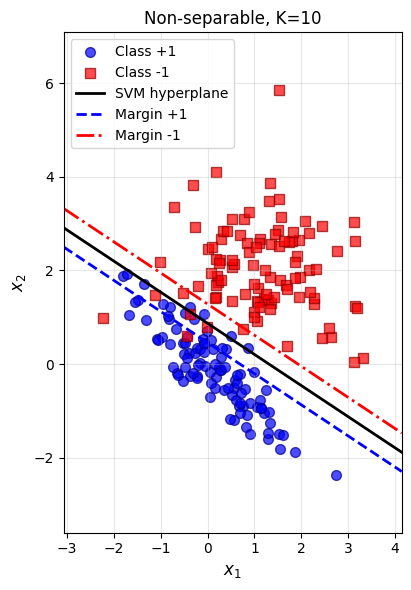

K=100
w: [-1.61325806 -2.43353943]
b: 2.118212038720091


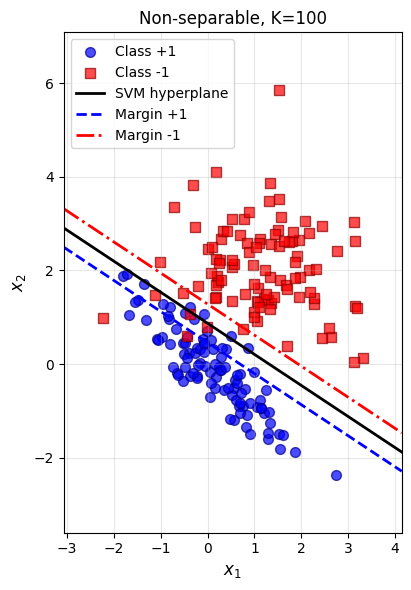

K=1000000.0
w: [-1.61325806 -2.43353944]
b: 2.1182120426065976


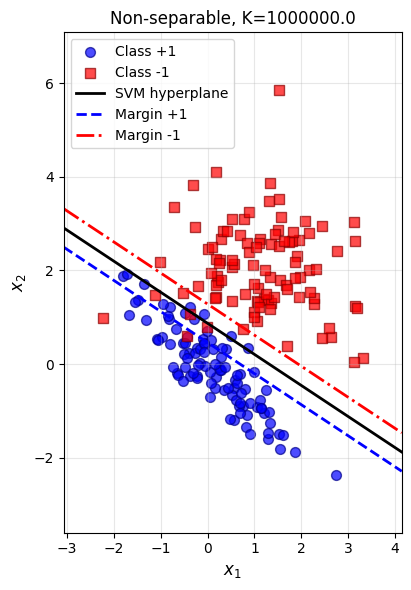

K=1000000000000.0
w: [ 9.63915002e+14 -4.23287179e+15]
b: -433922387178299.3


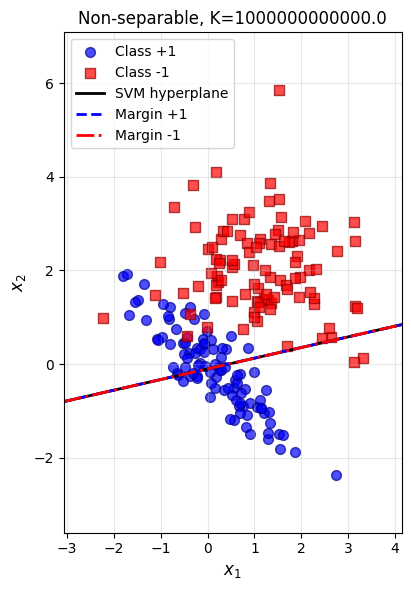

In [31]:
# Experiment 3: Non-separable dataset, 100 samples per class, multiple K values
K_values_nonsep = [0.001, 0.1, 1, 10, 100, 1e6, 1e12]
for K in K_values_nonsep:
    X_nonsep, y_nonsep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)
    w_nonsep, b_nonsep, _ = SVM_hyperplane(X_nonsep, y_nonsep, K=K)
    print(f"K={K}")
    print("w:", w_nonsep)
    print("b:", b_nonsep)
    plot_svm_with_margin(X_nonsep, y_nonsep, w_nonsep, b_nonsep, title=f"Non-separable, K={K}")
    plt.tight_layout()
    plt.show()


Similarly as before, in this case, when we change the value of $K$ across a range of several values, we can notice that with small $K$ values, the confidence margin becomes wider because we are increasing the tolerance for violations of the margin. In the case of $K = 0.001$,  most of the points are outside the margin, because we can not classify them with enough confidence for that $K$ parameter. If we set the $K$ parameter to 1, we get a good balance of missclassified points outside of the margin. When we weep increasing the $K$ value, the margin gets narrower because this means that we are reducing our tolerance to missclassified points. When we reach values that are too high, the method stops converging in a correct separation line, missclassifing a lot of the points. 

So, to conclude this final experiment, the SVM is applied to a non-separable dataset with 100 samples per class in order to analyze the influence of the regularization parameter $K$ when perfect separation is not possible. In this scenario, some data points necessarily violate the margin constraints, which implies that the slack variables $\xi_i$ become active and play a central role in the optimization problem. For moderate values of $K$, such as $K = 1$, the resulting hyperplane represents a compromise between maximizing the margin and allowing a controlled number of misclassifications. The decision boundary $f(x) = w^T x + b$ crosses regions of overlap between the two classes, and several points lie inside the margin or even on the wrong side of the hyperplane, reflecting the soft-margin nature of the solution. As $K$ is increased to larger values, such as $K = 10^6$, the penalty for misclassification becomes much stronger, and the SVM prioritizes reducing classification errors over maintaining a wide margin. This results in a noticeable shift of the separating hyperplane, which adapts its orientation and position to correctly classify a larger fraction of samples, even at the cost of a narrower margin. For extremely large values of $K$, the optimization problem becomes numerically unstable, leading to excessively large values of the parameters $w$ and $b$ and to a nearly vertical separating hyperplane. This behavior is not a theoretical failure of the SVM formulation, but rather a consequence of numerical instability caused by ill-conditioned optimization when the box constraints $0 \leq \alpha_i \leq K$ are effectively removed. Overall, this experiment demonstrates that, unlike the separable case, the value of $K$ has a direct and significant impact on the solution in the non-separable setting, controlling the balance between margin maximization and misclassification tolerance.
